In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import allantools
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei'] 

# 2.核心修复：如果设置 False 后仍乱码，请确保这一行在所有绘图命令之前
plt.rcParams['axes.unicode_minus'] = False 

# 3.针对 VS Code Jupyter 的额外保险：强制数学公式字体采用 CM
# 这通常能解决坐标轴负号和数学符号的渲染冲突
plt.rcParams['mathtext.fontset'] = 'cm'

In [ ]:
def process_frequency_data(freq_raw, tau0, f0):
    """
    计算去漂移和归一化数据
    """
    time_axis = np.arange(len(freq_raw)) * tau0
    
    # 线性拟合 (去长漂)
    p = np.polyfit(time_axis, freq_raw, 1)
    freq_drift = np.polyval(p, time_axis)
    freq_detrended = freq_raw - freq_drift
    
    # 归一化 (注意：原始数据算MDEV通常减均值，去漂后算MDEV用去漂值)
    y_original = (freq_raw - np.mean(freq_raw)) / f0
    y_detrended = freq_detrended / f0
    
    return {
        'time': time_axis,
        'freq_raw': freq_raw,
        'freq_drift': freq_drift,
        'freq_detrended': freq_detrended,
        'y_original': y_original,
        'y_detrended': y_detrended,
        'drift_params': p # p[0] is slope, p[1] is intercept
    }

def calculate_mdev(y_data, tau0):
    """计算 Modified Allan Deviation"""
    (taus, mdev, _, _) = allantools.mdev(y_data, rate=1/tau0, data_type='freq', taus='decade')
    return taus, mdev

# ==========================================
# 2. 绘图函数封装
# ==========================================

def plot_time_domain_single(processed, label, custom_text):
    """
    [新增] 画单组数据的时域图：包含原始拟合 & 去漂后数据
    对应你原始代码的 Figure 1
    """
    time = processed['time']
    raw = processed['freq_raw']
    drift = processed['freq_drift']
    detrended = processed['freq_detrended']
    slope = processed['drift_params'][0]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), dpi=150) # dpi稍低一点防止多图太卡
    
    # 子图1: 原始数据 + 拟合线
    ax1.plot(time, raw, color='gray', alpha=0.6, label='Original Data')
    ax1.plot(time, drift, 'r--', linewidth=2, label=f'Drift Fit: {slope:.4e} Hz/s')
    ax1.set_ylabel('Frequency (Hz)')
    ax1.set_title(f'Frequency vs Time: {label} (Raw & Drift Fit)')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)

    # 子图2: 去漂后数据
    ax2.plot(time, detrended, color='#004488', label='Detrended Data')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel(r'$\Delta$ Frequency (Hz)')
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)

    # 中间水印
    fig.text(0.5, 0.5, custom_text, 
             ha='center', va='center', 
             fontsize=30, color='gray', alpha=0.3, weight='bold', rotation=30)
    
    plt.tight_layout()
    # 注意：在循环中不建议直接 show() 阻塞，可以最后一起 show，或者这里不写 show 由外部控制

def plot_mdev_comparison(results_buffer, custom_text):
    fig, ax = plt.subplots(figsize=(10, 7), dpi=300)

    # 使用 enumerate 获取索引 i，用于计算偏移量
    for i, res in enumerate(results_buffer):
        conf = res['config']
        mdev = res['mdev']
        color = conf.get('color', 'blue')

        # 画曲线
        ax.loglog(mdev['t_orig'], mdev['v_orig'], '--', color=color, alpha=0.3, label=f"{conf['label']} (Raw)")
        ax.loglog(mdev['t_detr'], mdev['v_detr'], 'd-', color=color, markersize=5, linewidth=2, label=f"{conf['label']} (Detrended)")

        # --- 优化后的标注逻辑 ---
        idx = np.argmin(np.abs(mdev['t_detr'] - 1.0))
        val_1s = mdev['v_detr'][idx]
        real_tau = mdev['t_detr'][idx]
        
        # 核心修改：计算动态偏移
        # 基础除数是 4 (即 val_1s / 4)，每多一组数据，除数乘以 3
        # 这样第一组在下方，第二组在更下方，第三组在更更下方...
        # 1.5 是控制垂直间距的系数，你可以改为 2.0 让间距更大
        y_offset_divider = 1 * (1.5 ** i) 
        # y_offset_divider = 6
        
        # 为了美观，也可以让文字稍微左右错开一点点 (可选)
        # x_offset_multiplier = 0.6 if i % 2 == 0 else 0.8 
        x_offset_multiplier = 0.2 + i*i # 保持对齐
        
        ax.annotate(f'1s: {val_1s:.2e}', 
                    xy=(real_tau, val_1s), # 箭头尖端位置（不变）
                    
                    # 文本位置（动态计算）
                    xytext=(real_tau * x_offset_multiplier, val_1s / y_offset_divider),
                    
                    arrowprops=dict(facecolor=color, shrink=0.05, width=1, headwidth=6),
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=color, alpha=0.8),
                    fontsize=9)

    # 其他绘图设置保持不变...
    ax.text(0.5, 0.5, custom_text, transform=ax.transAxes,
            ha='center', va='center', fontsize=25, color='gray', alpha=0.2, weight='bold')
    ax.set_xlabel('Tau (s)')
    ax.set_ylabel(r'Mod $\sigma_y(\tau)$')
    ax.set_title('Modified Allan Deviation Comparison')
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    plt.tight_layout()

处理中: 8cm 腔前后拍，技物所激光器驱动板 (数据点: 6630)


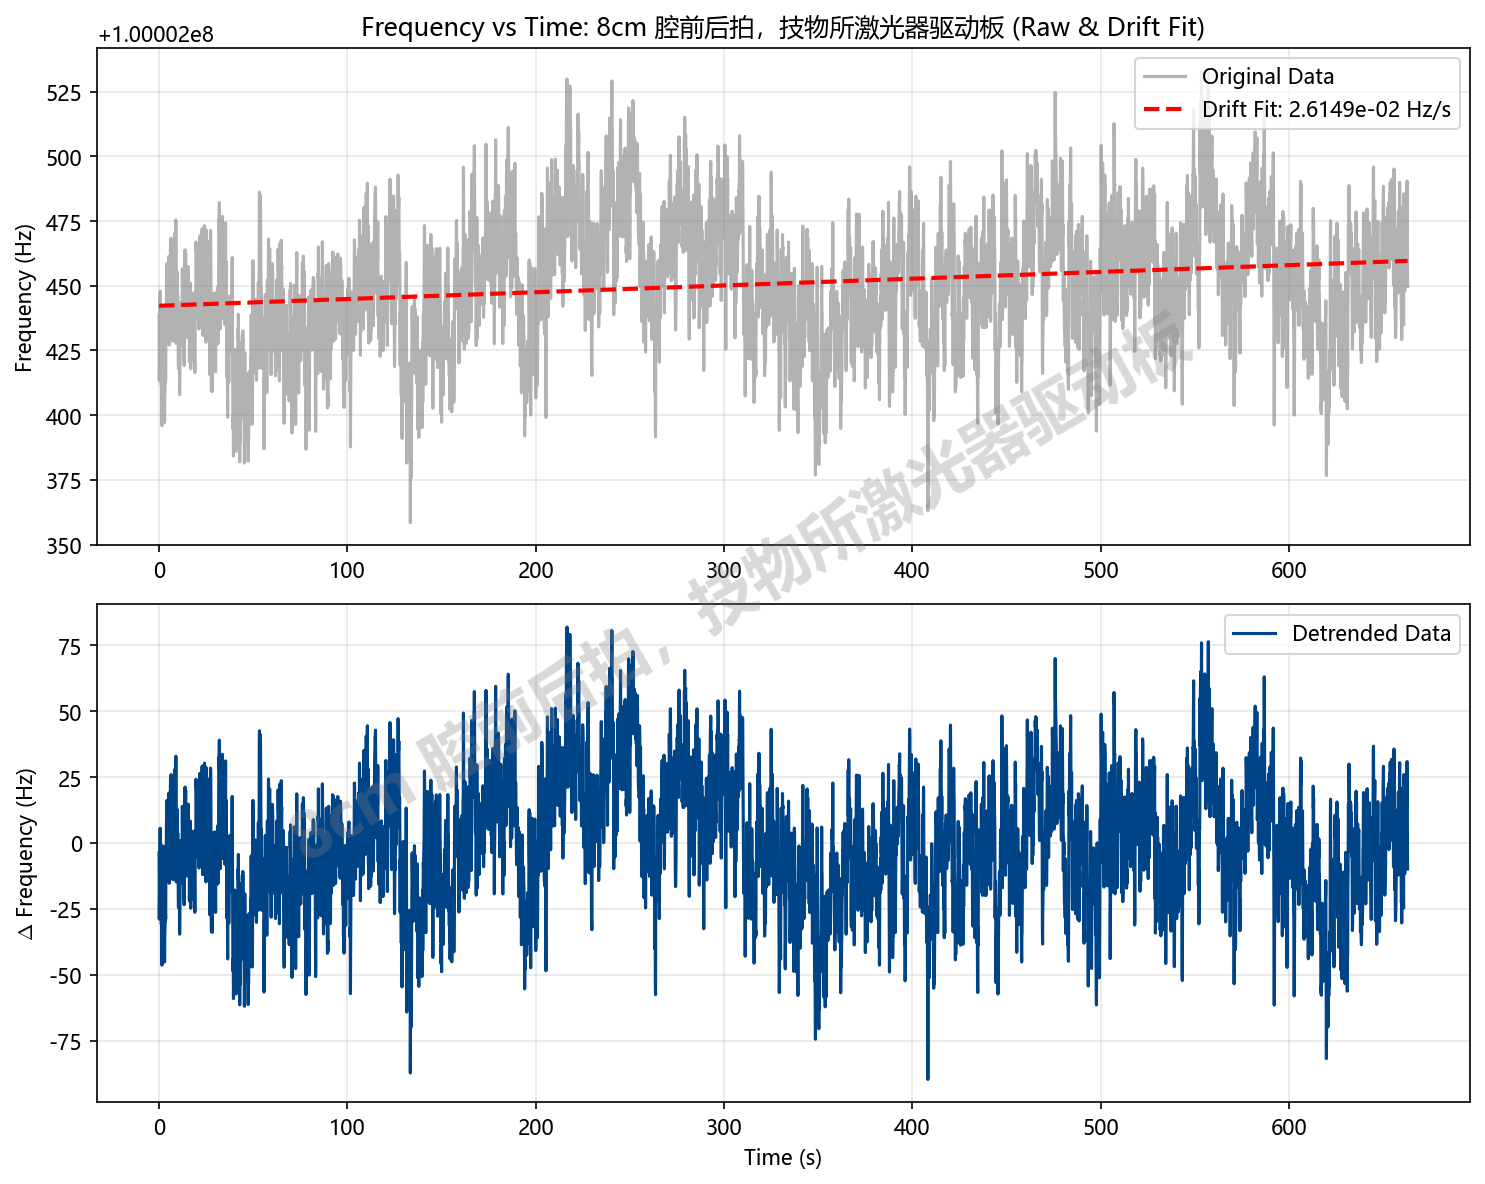

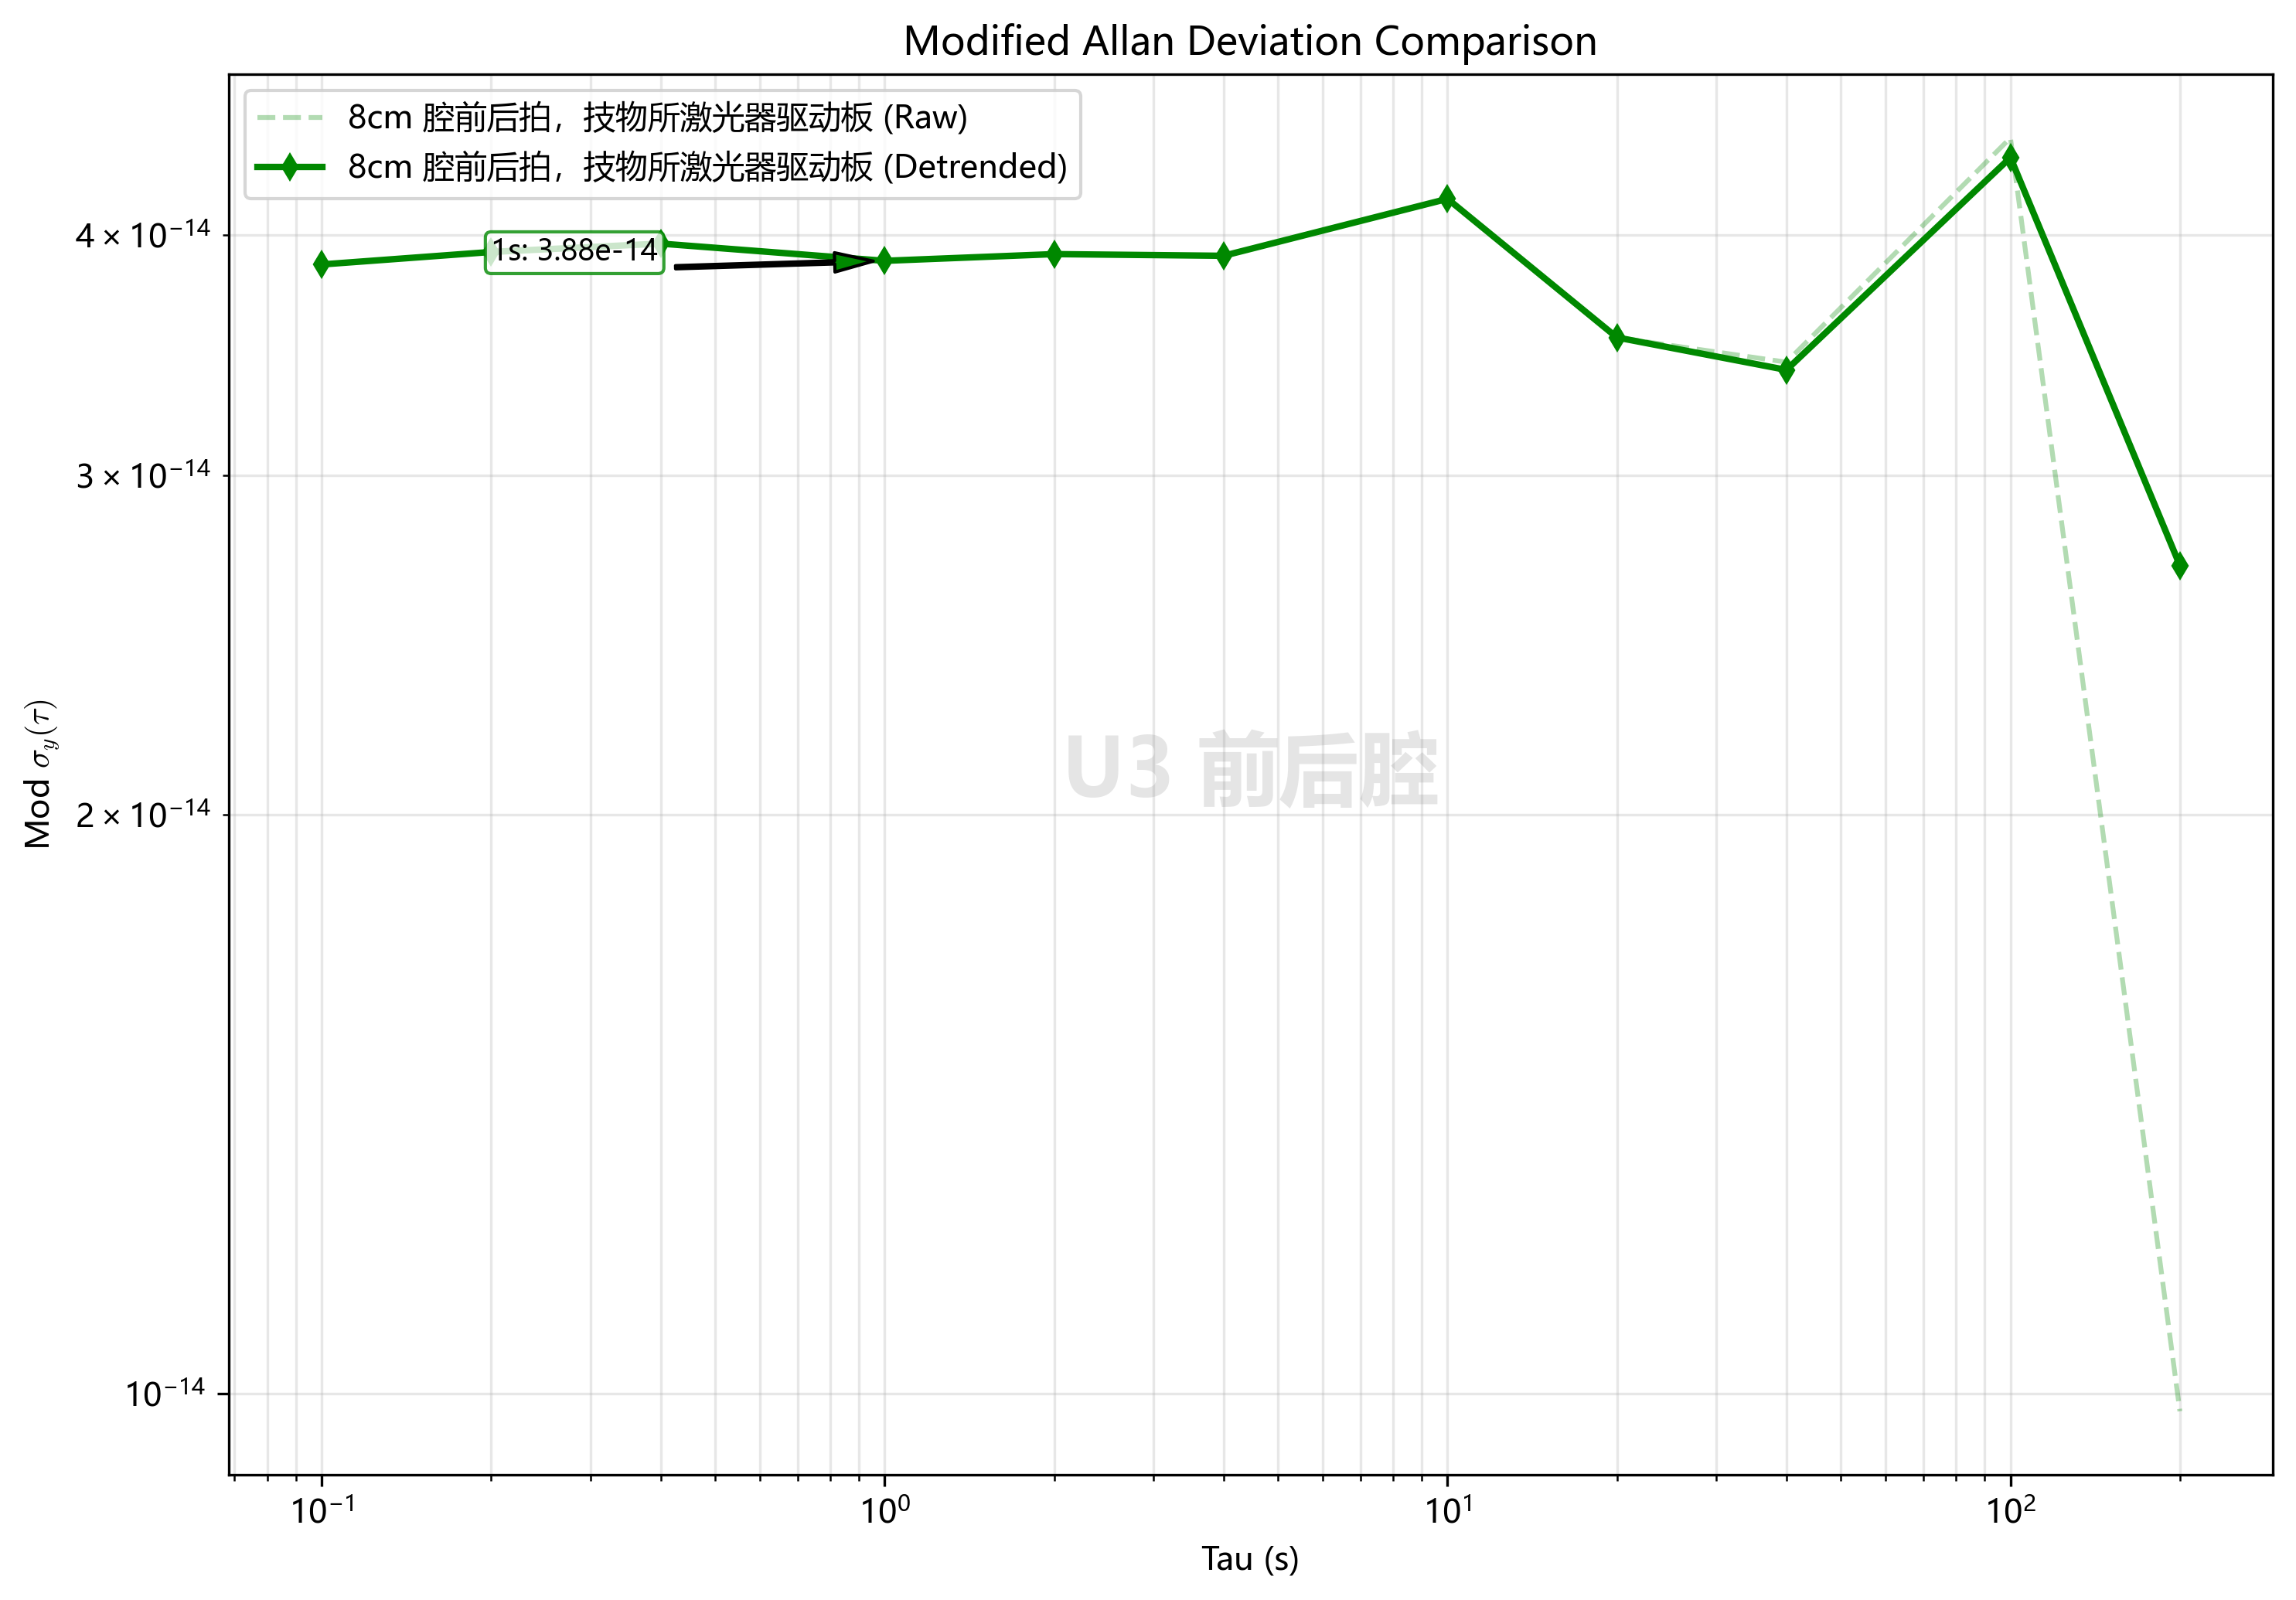

In [ ]:
# ==========================================
# 3. 主程序
# ==========================================

# --- 参数 ---
lambda_nm = 1397.0
f0 = 299792458.0 / (lambda_nm * 1e-9)

my_custom_text = "U3 前后腔" 

# --- 数据配置列表 ---
data_configs = [
    {
        'file': '20260429——电1电2拍频，采样率10Hz.csv', 
        'label': '8cm 腔前后拍，技物所激光器驱动板', 
        'cut_ratio_lower': 0.01, 
        'cut_ratio_upper': 0.1,
        'color': '#008800',
        'tau': 0.1
    }
    
]

results_buffer = []

# --- 循环处理 ---
for config in data_configs:
    try:
        # 1. 读取
        raw_data_full = np.loadtxt(config['file'])
        time_row = raw_data_full[:, 1] if raw_data_full.ndim > 1 else np.arange(len(raw_data_full)) * config['tau']
        freq_raw_full = raw_data_full[:, 3] if raw_data_full.ndim > 1 else raw_data_full
        
        # 截取
        start_index = int(len(freq_raw_full) * config['cut_ratio_lower'])
        end_index = int(len(freq_raw_full) * config['cut_ratio_upper'])
        freq_raw = freq_raw_full[start_index:end_index]
        
        print(f"处理中: {config['label']} (数据点: {len(freq_raw)})")

        # 2. 计算 (去漂 + 归一化)
        processed = process_frequency_data(freq_raw, config['tau'], f0)
        
        # 3. 【新增】画时域图 (Figure 1: 拟合 vs 去漂)
        plot_time_domain_single(processed, config['label'], config['label'])

        # 4. 计算 MDEV
        t1, m_orig = calculate_mdev(processed['y_original'], config['tau'])
        t2, m_detr = calculate_mdev(processed['y_detrended'], config['tau'])
        
        # 5. 保存结果用于最后汇总
        results_buffer.append({
            'config': config,
            'mdev': {'t_orig': t1, 'v_orig': m_orig, 't_detr': t2, 'v_detr': m_detr}
        })

    except Exception as e:
        print(f"Error processing {config['file']}: {e}")

# --- 最后画汇总图 ---
if results_buffer:
    # 画 MDEV 汇总图 (Figure 2)
    plot_mdev_comparison(results_buffer, my_custom_text)
    
    # 统一显示所有图片
    plt.show()